# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [1]:
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules
# Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Your code here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [2]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [3]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
print(df.info())


print("\nFirst 5 rows:")
print(df.head())


print("\nBasic Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB
None

First 5 rows:
   Dom_Flt  Int_Flt    Flt  Dom_Pax  Int_Pax     Pax    Dom_RPM
0    16490     8715  25205   152866   176257  329123  124207802
1    14585     9121  23706   148316   136571  284888  112284645
2    16943    10166  27109   212190   156317  368508  172347465
3    19569    10107  29676   250224   127892  378116  213773981
4    14297     5244  19542   162835    82306  245142  131063749

Basic Statistics:
            Dom_Flt       Int_Flt           Flt        Dom_Pax        Int_Pax  \
count    200.00

In [4]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
print(df.isnull().sum())


# Handle missing values if any (uncomment and complete if needed)
if df.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    df = df.fillna(0)  # Replace missing values with 0
    print(f"New shape after handling missing values: {df.shape}")

Missing values:
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_RPM    0
dtype: int64


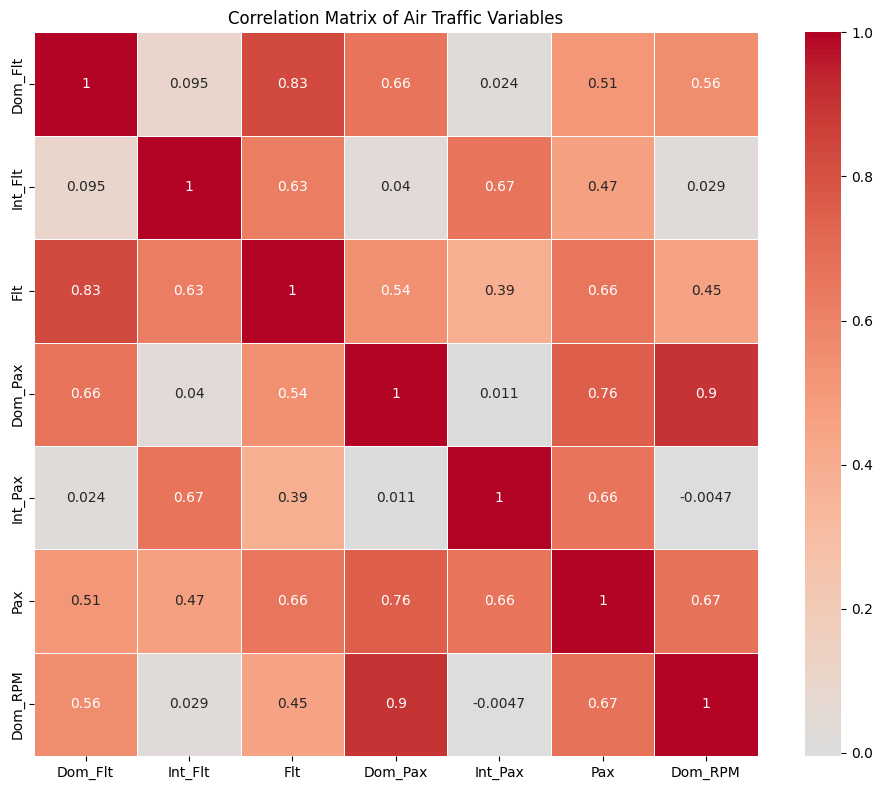

Strongest correlations:
Dom_Flt  Dom_Flt    1.000000
Dom_RPM  Dom_Pax    0.901617
Flt      Dom_Flt    0.834910
Dom_Pax  Pax        0.755916
Dom_RPM  Pax        0.672074
Int_Flt  Int_Pax    0.665554
Dom_Flt  Dom_Pax    0.664181
Pax      Int_Pax    0.662822
Flt      Pax        0.659231
         Int_Flt    0.627340
Dom_RPM  Dom_Flt    0.559946
Dom_Pax  Flt        0.541947
Dom_Flt  Pax        0.513322
Pax      Int_Flt    0.466015
Flt      Dom_RPM    0.453840
         Int_Pax    0.387060
Dom_Flt  Int_Flt    0.095161
Int_Flt  Dom_Pax    0.040427
Dom_RPM  Int_Flt    0.028555
Dom_Flt  Int_Pax    0.024392
Int_Pax  Dom_Pax    0.010837
         Dom_RPM   -0.004699
dtype: float64


In [5]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr()

# Create heatmap:
# TODO: Use sns.heatmap() with parameters: annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5


plt.title('Correlation Matrix of Air Traffic Variables')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.tight_layout()
plt.show()

# TODO: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations:")
print(correlation_matrix.unstack().sort_values(ascending=False).drop_duplicates())


Il y a une forte corrélation entre Dom_RPM et Dom_Pax, Flt et Dom_Flt, Dom_Pax et Pax, Dom_RPM et Pax

## 3. Hypothesis Testing

In [6]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# TODO: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # TODO: Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("Il existe une difference significative entre la moyenne des deux groupes")
else:
    # TODO: Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("La moyenne des 2 groupes sont significativement égale")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
Il existe une difference significative entre la moyenne des deux groupes


In [7]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# TODO: Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # TODO: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print("A mesure que le nombre total de vols augmente, le nombre total de passagers tend également à augmenter")
    else:
        print("Plus le nombre total de vols augmente, plus le nombre total de passagers tend à diminuer.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Il n'y pas de corrélation entre le nombres passagers et nombres de vols ")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
A mesure que le nombre total de vols augmente, le nombre total de passagers tend également à augmenter


## 4. Simple Linear Regression

In [8]:
# TODO: Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']]  # Total Flights
y_simple = df['Pax']  # Total Passengers

# Split the data:
# TODO: Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create and train the model:
simple_model = LinearRegression()
# TODO: Fit the model using X_train_simple and y_train_simple
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# TODO: Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# TODO: Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


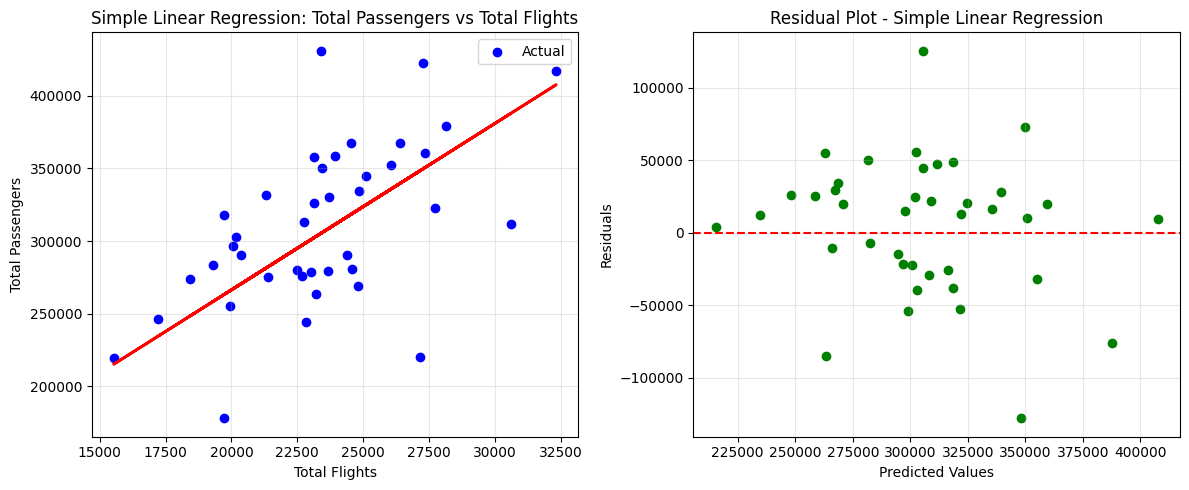

In [9]:
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line

plt.scatter(X_test_simple, y_test_simple, color='blue', label='Actual')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2)
plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
# residuals = actual - predicted
residuals = y_test_simple - y_pred_simple

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();

## 5. Multiple Linear Regression

In [10]:
# TODO: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# TODO: Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
feature_columns = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']

X_multiple = df[feature_columns]
y_multiple = df['Pax']

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# TODO: Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# TODO: Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

# TODO: Create and train the multiple regression model
multiple_model = LinearRegression()
# TODO: Fit the model

multiple_model.fit(X_train_mult_scaled, y_train_mult)

# TODO: Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# TODO: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# TODO: Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Feature Coefficients (after scaling):
Dom_Pax: 45354.3590
Int_Pax: 38979.7965
Dom_Flt: -0.1126
Int_Flt: -0.0583
Dom_RPM: -0.0458
Intercept: 300303.27


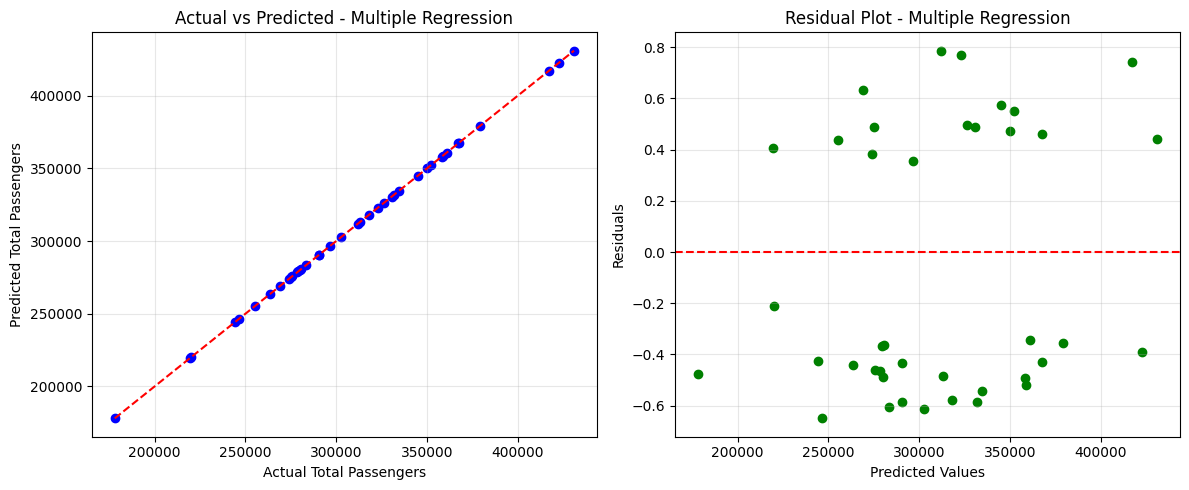

In [11]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# TODO: Add a diagonal reference line (perfect prediction line)
plt.scatter(y_test_mult, y_pred_mult, color='blue')
plt.plot([min(y_test_mult), max(y_test_mult)], [min(y_test_mult), max(y_test_mult)], color='red', linestyle='--')
plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [12]:
# TODO: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# TODO: Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections



print("=" * 50)

# TODO: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = (r2_mult - r2_simple) / r2_simple * 100
else:
    better_model = "Simple Regression"
    improvement = (r2_simple - r2_mult) / r2_simple * 100

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 

Best Model: Multiple Regression
R² Improvement: 235.92%


## 7. Statistical Insights and Conclusions

In [16]:
print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
# TODO: Summarize your hypothesis test results
print(f"   • Domestic vs International Passengers: \n Il existe une difference significative entre la moyenne des deux groupes")
print(f"   • Correlation between Total Passengers and Flights: \n A mesure que le nombre total de vols augmente, le nombre total de passagers tend également à augmenter")

print("\n2. REGRESSION ANALYSIS:")
# TODO: Summarize regression model performance
print(f"   • Simple Linear Regression R²: \n R² = {round(r2_simple,2)} : Les prédiction du modèle ne sont pas totalement exacte")
print(f"   • Multiple Linear Regression R²: \n R² = {round(r2_mult,2)} : Les prédictions du modèles sont 100% exactes")
print(f"   • Best performing model: {better_model}")

print("\n3. KEY FINDINGS:")

print(f" • Le volume de passagers domestiques est nettement supérieur au volume de passagers internationaux.")
print(f" • Il existe une forte corrélation positive entre le nombre total de passagers et le nombre total de vols, ce qui indique qu'une augmentation du nombre de vols entraîne généralement une augmentation du nombre de passagers.")
print(f" • Le modèle de régression linéaire multiple a atteint un R² quasi parfait (1,0) car 'Pax' (Nombre total de passagers) est la somme directe de 'Dom_Pax' et 'Int_Pax'. Cela indique une fuite de données, et le modèle n'est pas véritablement prédictif au sens général, mais reflète plutôt une relation de définition.")

print("\n4. RECOMMANDATIONS :")

print(" • Réévaluer la sélection des variables pour le modèle de régression linéaire multiple afin d'éviter les fuites de données. Envisager de prédire le nombre total de passagers en utilisant uniquement des variables indépendantes telles que 'Dom_Flt', 'Int_Flt' et 'Dom_RPM' pour un modèle prédictif plus réaliste.")
print(" • Compte tenu du R² nettement supérieur Compte tenu du volume de passagers sur les vols intérieurs, les compagnies aériennes pourraient explorer des stratégies pour améliorer encore l'expérience de voyage et développer leurs liaisons intérieures.")
print(" • La forte corrélation positive entre les vols et le nombre de passagers suggère que l'optimisation des horaires et de la capacité des vols peut avoir un impact direct sur le nombre de passagers.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: 
 Il existe une difference significative entre la moyenne des deux groupes
   • Correlation between Total Passengers and Flights: 
 A mesure que le nombre total de vols augmente, le nombre total de passagers tend également à augmenter

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 
 R² = 0.3 : Les prédiction du modèle ne sont pas totalement exacte
   • Multiple Linear Regression R²: 
 R² = 1.0 : Les prédictions du modèles sont 100% exactes
   • Best performing model: Multiple Regression

3. KEY FINDINGS:
 • Le volume de passagers domestiques est nettement supérieur au volume de passagers internationaux.
 • Il existe une forte corrélation positive entre le nombre total de passagers et le nombre total de vols, ce qui indique qu'une augmentation du nombre de vols entraîne généralement une augmentation du nombre de passagers.
 • Le modèle de régression linéaire multip

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

-> Nos hypothèses concernant le trafic aérien ont révélé que plus le nombre de vols augmentait, celui de passagers aussi, ce qui confirmait notre hypothèse de départ de savoir s'il y avait une corrélation entre les deux.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

-> La regression linéaire multiple performe mieux car il ne se base pas sur une seul caractérisque, mais sur plusieurs caractérisque pour prédire au mieux le résultats et r² mésure la performance du modèle qui de 1, soit 100% de précision

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

-> Les corrélations les plus fortes ont été observées entre 'Dom_RPM' et 'Dom_Pax' (0,90), 'Dom_Pax' et 'Pax' (0,76), et 'Int_Flt' et 'Int_Pax' (0,67). Ces relations sont cruciales pour les compagnies aériennes car elles indiquent que les passagers domestiques sont le principal moteur des revenus par passager-mile (Dom_RPM) et contribuent significativement au nombre total de passagers. De même, une augmentation des vols internationaux est directement liée à une augmentation des passagers internationaux. Les compagnies aériennes peuvent utiliser ces informations pour optimiser leurs stratégies de tarification, allouer des ressources (par exemple, la taille des avions, la fréquence des vols) aux routes domestiques et internationales les plus rentables, et planifier leurs capacités plus efficacement.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

-> Pour le modèle de régression linéaire simple, le diagramme des résidus montre une dispersion des points plutôt aléatoire autour de zéro, bien qu'il y ait une légère tendance en forme d'entonnoir, suggérant que la variance des erreurs pourrait ne pas être constante (hétéroscédasticité). Cela indique que la performance du modèle pourrait varier pour différentes plages de valeurs prédites. Pour le modèle de régression linéaire multiple, les résidus sont extrêmement proches de zéro, ce qui est cohérent avec le R² de 1,0. Cependant, comme mentionné précédemment, cela est dû à une fuite de données ('Pax' étant la somme directe de 'Dom_Pax' et 'Int_Pax'), ce qui signifie que ce modèle ne généralisera pas bien à de nouvelles données où 'Pax' n'est pas simplement une somme. Une amélioration pour le modèle simple pourrait être d'explorer des transformations de données ou d'ajouter d'autres variables pertinentes. Pour le modèle multiple, il est impératif de resélectionner les caractéristiques pour éliminer la fuite de données et construire un modèle véritablement prédictif.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

-> Les compagnies aériennes pourraient utiliser ces modèles pour :
   - **Prévision de la Demande**: Prédire le nombre futur de passagers (Dom_Pax, Int_Pax, Pax) et les revenus (Dom_RPM) pour mieux planifier les horaires, les allocations de personnel et la capacité de la flotte.
   - **Optimisation des Prix**: Comprendre comment les changements dans le nombre de vols (Dom_Flt, Int_Flt) influencent la demande de passagers peut aider à ajuster les stratégies de tarification pour maximiser les revenus.
   - **Allocation des Ressources**: Basées sur les prévisions, les compagnies aériennes peuvent allouer leurs ressources (par exemple, carburant, maintenance, équipage) plus efficacement aux routes qui devraient avoir le trafic le plus élevé.
   - **Analyse Stratégique**: Évaluer l'impact potentiel de l'expansion de nouvelles routes ou de l'ajustement de la fréquence des vols sur la rentabilité globale et la part de marché.